
Bad key axes3d.automargin in file /home/cgw/anaconda3/envs/multi310/lib/python3.10/site-packages/matplotlib/mpl-data/matplotlibrc, line 430 ('axes3d.automargin: False  # automatically add margin when manually setting 3D axis limits')
You probably need to get an updated matplotlibrc file from
https://github.com/matplotlib/matplotlib/blob/v3.8.2/lib/matplotlib/mpl-data/matplotlibrc
or from the matplotlib source distribution

Bad key image.interpolation_stage in file /home/cgw/anaconda3/envs/multi310/lib/python3.10/site-packages/matplotlib/mpl-data/matplotlibrc, line 606 ('image.interpolation_stage: data     # see help(imshow) for options')
You probably need to get an updated matplotlibrc file from
https://github.com/matplotlib/matplotlib/blob/v3.8.2/lib/matplotlib/mpl-data/matplotlibrc
or from the matplotlib source distribution


torch.Size([99600, 63, 11, 11])
Prediction completed in 11.38 seconds
Prediction label image saved at ./Trento/Trento_predicted_labelsbest.png


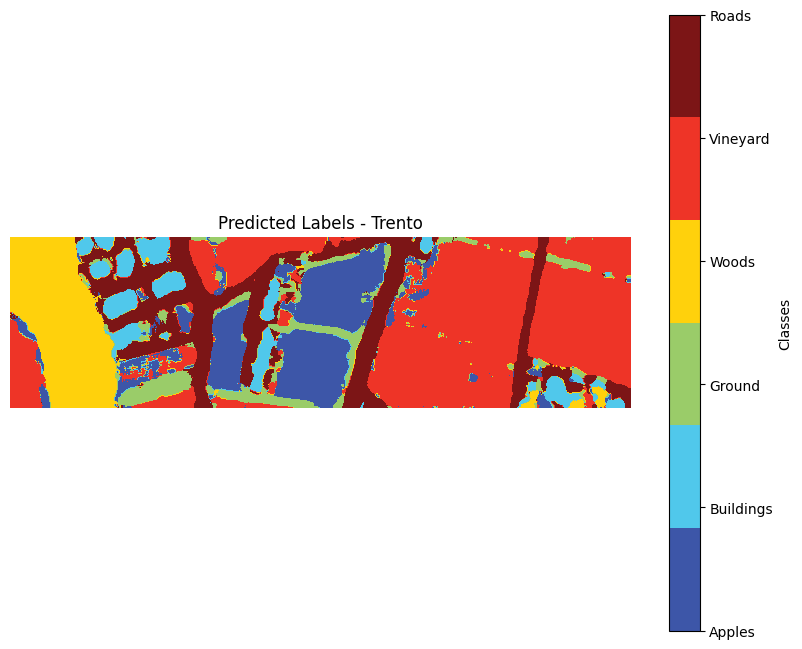

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap
import os
from scipy import io
import torch
import time

os.environ["CUDA_VISIBLE_DEVICES"]="1"
datasetNames = ["Trento"]

HSIOnly = False
testSizeNumber = 500

def create_full_patches(Data1, Data2, patchsize, pad_width):
    # Data1: HSI 图像 [166, 600, 63]
    # Data2: LiDAR 图像 [166, 600, 1]
    m1, n1, l1 = Data1.shape
    Data2 = Data2.view(m1, n1, -1).numpy()  # Convert to NumPy for processing

    m2, n2, l2 = Data2.shape

    Data1_np = Data1.numpy()
    Data2_np = Data2.copy()

    # 归一化 Data1
    for i in range(l1):
        min_val = Data1_np[:, :, i].min()
        max_val = Data1_np[:, :, i].max()
        if max_val - min_val != 0:
            Data1_np[:, :, i] = (Data1_np[:, :, i] - min_val) / (max_val - min_val)
        else:
            Data1_np[:, :, i] = 0.0  # 避免除以零

    # 归一化 Data2
    for i in range(l2):
        min_val = Data2_np[:, :, i].min()
        max_val = Data2_np[:, :, i].max()
        if max_val - min_val != 0:
            Data2_np[:, :, i] = (Data2_np[:, :, i] - min_val) / (max_val - min_val)
        else:
            Data2_np[:, :, i] = 0.0  # 避免除以零

    # 填充数据
    x1_pad = np.empty((m1 + 2 * pad_width, n1 + 2 * pad_width, l1), dtype='float32')
    x2_pad = np.empty((m2 + 2 * pad_width, n2 + 2 * pad_width, l2), dtype='float32')

    for i in range(l1):
        temp = Data1_np[:, :, i]
        x1_pad[:, :, i] = np.pad(temp, ((pad_width, pad_width), (pad_width, pad_width)), 'symmetric')

    for i in range(l2):
        temp = Data2_np[:, :, i]
        x2_pad[:, :, i] = np.pad(temp, ((pad_width, pad_width), (pad_width, pad_width)), 'symmetric')

    # 构造全图像 patch
    total_pixels = m1 * n1
    FullPatch1 = np.empty((total_pixels, l1, patchsize, patchsize), dtype='float32')
    FullPatch2 = np.empty((total_pixels, l2, patchsize, patchsize), dtype='float32')

    index = 0
    for i in range(pad_width, m1 + pad_width):
        for j in range(pad_width, n1 + pad_width):
            patch1 = x1_pad[i - pad_width:i + pad_width + 1, j - pad_width:j + pad_width + 1, :]
            FullPatch1[index] = patch1.transpose(2, 0, 1)  # (l1, patchsize, patchsize)

            patch2 = x2_pad[i - pad_width:i + pad_width + 1, j - pad_width:j + pad_width + 1, :]
            FullPatch2[index] = patch2.transpose(2, 0, 1)  # (l2, patchsize, patchsize)

            index += 1

    # 转换为 PyTorch 张量
    FullPatch1 = torch.from_numpy(FullPatch1)
    FullPatch2 = torch.from_numpy(FullPatch2)

    return FullPatch1, FullPatch2

lidardim = 1
if datasetNames == ['Houston']:
    colors = np.array([[0, 0, 205],
                       [0, 8, 255],
                       [0, 77, 255],
                       [0, 145, 255],
                       [0, 212, 255],
                       [41, 255, 206],
                       [96, 255, 151],
                       [151, 255, 96],
                       [206, 255, 41],
                       [255, 230, 0],
                       [255, 167, 0],
                       [255, 104, 0],
                       [255, 41, 0],
                       [205, 0, 0],
                       [128, 0, 0]]) / 255.0
    Classes = 15
    FileName = 'MMamba_houston'
elif datasetNames == ['Trento']:
    colors = np.array([[61, 86, 168],
                       [80, 200, 235],
                       [154, 204, 105],
                       [255, 209, 12],
                       [238, 52, 39],
                       [124, 21, 22]]) / 255.0
    Classes = 6
    FileName = 'MMamba_trento'
elif datasetNames == ['Muufl']:
    colors = np.array([[0, 128, 1],
                       [0, 255, 1],
                       [0, 255, 255],
                       [254, 203, 0],
                       [252, 0, 49],
                       [2, 1, 203],
                       [102, 1, 205],
                       [254, 126, 151],
                       [201, 102, 0],
                       [254, 254, 0],
                       [204, 26, 100]]) / 255.0
    lidardim = 2
    Classes = 11
    FileName = 'MMamba_muufl'

cmap = ListedColormap(colors)

TrainData1 = io.loadmat('./../Data/' + str(datasetNames[0]) + '/hsi.mat')
TrainData2 = io.loadmat('./../Data/' + str(datasetNames[0]) + '/lidar.mat')
telabel = io.loadmat('./../Data/' + str(datasetNames[0]) + '/telabel.mat')
te = torch.from_numpy(telabel['Data'].astype(np.float32)).float()
Data1 = torch.from_numpy(TrainData1['Data']).to(torch.float32)
Data2 = torch.from_numpy(TrainData2['Data']).to(torch.float32)
height = Data1.shape[0]
width = Data1.shape[1]

patchsize = 11
pad_width = (patchsize - 1) // 2

Data1, Data2 = create_full_patches(Data1, Data2, patchsize, pad_width)

print(Data1.shape)

# model = MMamba(FM=8, NC=Data1.shape[1], NCLidar=lidardim, Classes=Classes, HSIOnly=HSIOnly, patchsize=11, drop_path=0.0, depth=2).cuda()

# Load the saved parameters
model = torch.load(datasetNames[0] + '/best_model_' + FileName + '_BandSize1_Iter0.pt')

model.eval()

pred_y = np.empty((Data1.shape[0]), dtype='float32')
number = len(Data1) // testSizeNumber  # 确定批次数量

torch.cuda.synchronize()
start_test = time.time()

# 分批次预测
for i in range(number):
    temp = Data1[i * testSizeNumber:(i + 1) * testSizeNumber, :].cuda()
    temp1 = Data2[i * testSizeNumber:(i + 1) * testSizeNumber, :].cuda()
        
    temp2 = model(temp, temp1)  # 使用 HSI 和 LiDAR 进行预测
        
    temp3 = torch.max(temp2, 1)[1].squeeze()  # 获取预测的类别
    pred_y[i * testSizeNumber:(i + 1) * testSizeNumber] = temp3.cpu()  # 将结果保存到 CPU
        
    # 释放 GPU 内存
    del temp, temp1, temp2, temp3
    torch.cuda.empty_cache()

# 处理最后一批（如果有的话）
if (i + 1) * testSizeNumber < len(Data1):
    temp = Data1[(i + 1) * testSizeNumber:len(Data1), :].cuda()
    temp1 = Data2[(i + 1) * testSizeNumber:len(Data1), :].cuda()
        
    temp2 = model(temp, temp1)
        
    temp3 = torch.max(temp2, 1)[1].squeeze()
    pred_y[(i + 1) * testSizeNumber:len(Data1)] = temp3.cpu()

    del temp, temp1, temp2, temp3
    torch.cuda.empty_cache()

torch.cuda.synchronize()
end_test = time.time()

print(f"Prediction completed in {end_test - start_test:.2f} seconds")

# 重塑预测标签为原图尺寸
pred_y_reshaped = pred_y.reshape(height, width)  # 将预测结果重塑为原始图像尺寸

# 绘制预测标签图
plt.figure(figsize=(10, 8))
plt.imshow(pred_y_reshaped, cmap=cmap)  # 使用自定义的颜色映射

# 设置 colorbar 显示类别名称
cbar = plt.colorbar(ticks=range(Classes), label='Classes')

if datasetNames == ['Houston']:
   cbar.set_ticklabels([
    'Healthy grass', 'Stressed grass', 'Synthetic grass', 'Trees', 'Soil', 'Water',
    'Residential', 'Commercial', 'Road', 'Highway', 'Railway', 'Parking Lot 1',
    'Parking Lot 2', 'Tennis Court', 'Running Track'
])
elif datasetNames == ['Trento']:
   cbar.set_ticklabels(['Apples','Buildings', 'Ground', 'Woods', 'Vineyard', 'Roads'])
elif datasetNames == ['Muufl']:

    cbar.set_ticklabels(['Trees', 'Grass_Pure', 'Grass_Groundsurface', 'Dirt_And_Sand', 'Road_Materials', 'Water',
                        'Buildings', "Buildings'_Shadow",
                        'Sidewalk', 'Yellow_Curb', 'ClothPanels'])

plt.title(f"Predicted Labels - {datasetNames[0]}")
plt.axis('off')  # 隐藏坐标轴

# 保存预测标签图像
output_image_path = f'./{datasetNames[0]}/{datasetNames[0]}_predicted_labelsbest.png'
plt.savefig(output_image_path, dpi=300, bbox_inches='tight')
print(f"Prediction label image saved at {output_image_path}")

# 展示生成的图像
plt.show()
